<a href="https://colab.research.google.com/github/shahwaiz-9/Deep-Learning/blob/main/Transfer_Learning_(_GoogleNet_CNN_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3, EfficientNetB0
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.
Path to dataset files: /kaggle/input/cell-images-for-detecting-malaria


In [ ]:
print(f"Contents of the downloaded dataset directory '{path}':")
for item in os.listdir(path):
    print(item)

Contents of the downloaded dataset directory '/kaggle/input/cell-images-for-detecting-malaria':
cell_images


Dataset creation using Tensorflow generator

In [ ]:
image_dir = os.path.join(path, 'cell_images', 'cell_images')

img_height, img_width = 224, 224
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    image_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    label_mode='binary',
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    image_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    label_mode='binary',
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds)}")


Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
Class names: ['Parasitized', 'Uninfected']
Number of training batches: 689
Number of validation batches: 173


In [ ]:
from tensorflow.keras.applications.inception_v3 import preprocess_input

def solution(img_size=(224, 224, 3)):

    inputs = tf.keras.layers.Input(shape=img_size)

    # Scaling

    x = tf.keras.layers.Lambda(preprocess_input)(inputs)

    # Freezing base of the model

    base_model = InceptionV3(weights='imagenet', include_top=False, input_tensor=x)
    base_model.trainable = False

    # Attaching ANN part


    x = base_model.output

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(1024, activation='relu')(x)

    x = tf.keras.layers.Dropout(0.4)(x)

    sol = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=inputs, outputs=sol)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
model = solution()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/6
689/689 ━━━━━━━━━━━━━━━━━━━━ 156s 202ms/step - accuracy: 0.9054 - loss: 0.2459 - val_accuracy: 0.9265 - val_loss: 0.1987
Epoch 2/6
689/689 ━━━━━━━━━━━━━━━━━━━━ 52s 75ms/step - accuracy: 0.9229 - loss: 0.2010 - val_accuracy: 0.9318 - val_loss: 0.1790
Epoch 3/6
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 76ms/step - accuracy: 0.9292 - loss: 0.1868 - val_accuracy: 0.9320 - val_loss: 0.1754
Epoch 4/6
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.9327 - loss: 0.1794 - val_accuracy: 0.9176 - val_loss: 0.2085
Epoch 5/6
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.9354 - loss: 0.1703 - val_accuracy: 0.9359 - val_loss: 0.1703
Epoch 6/6
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.9370 - loss: 0.1664 - val_accuracy: 0.9358 - val_loss: 0.1714


Results

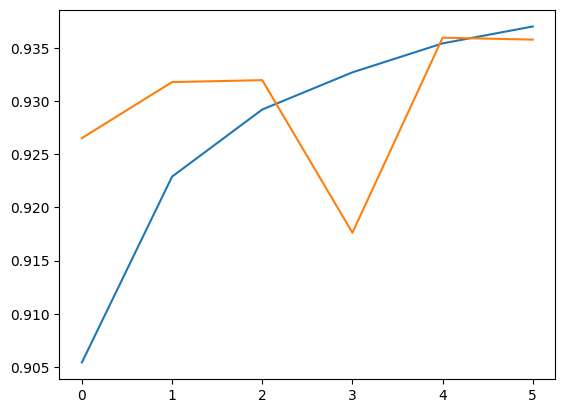

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

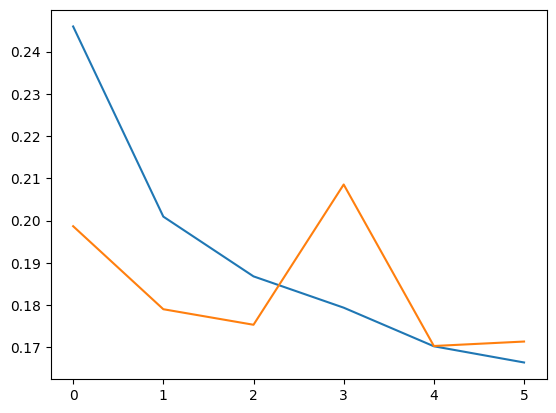

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

An Accuracy of 93% is decent enough we can increase this by some optimization.
 Also after 3rd iteration the accuracy doesn't evolved above 93%. SO running upto 3 iteration is fine enough.

In [ ]:
def create_fixed_inceptionv3_model(img_size=(224, 224, 3)):
    inputs = tf.keras.layers.Input(shape=img_size)

    # ✅ Preprocessing layer (handles [0,255] -> ImageNet format)
    x = tf.keras.layers.Lambda(
        tf.keras.applications.inception_v3.preprocess_input
    )(inputs)

    # Frozen InceptionV3
    base = tf.keras.applications.InceptionV3(
        include_top=False,
        weights='imagenet',
        input_tensor=x,
        pooling=None
    )
    base.trainable = False

    # Top head
    x = base.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    # ✅ Fixed compile
    model.compile(
        optimizer='adam',  # or 'rmsprop'
        loss='binary_crossentropy',  # ✅ FIXED
        metrics=['accuracy']
    )
    return model


In [ ]:
model1 = create_fixed_inceptionv3_model()

model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 86s 106ms/step - accuracy: 0.8914 - loss: 0.2643 - val_accuracy: 0.9125 - val_loss: 0.2204
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 57s 83ms/step - accuracy: 0.9199 - loss: 0.2087 - val_accuracy: 0.9278 - val_loss: 0.1889
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 56s 81ms/step - accuracy: 0.9280 - loss: 0.1946 - val_accuracy: 0.9267 - val_loss: 0.1874
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 56s 82ms/step - accuracy: 0.9292 - loss: 0.1915 - val_accuracy: 0.9300 - val_loss: 0.1814
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 56s 82ms/step - accuracy: 0.9289 - loss: 0.1894 - val_accuracy: 0.9300 - val_loss: 0.1807
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 67s 97ms/step - accuracy: 0.9310 - loss: 0.1843 - val_accuracy: 0.9343 - val_loss: 0.1822
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 66s 96ms/step - accuracy: 0.9307 - loss: 0.1839 - val_accuracy: 0.9329 - val_loss: 0.1917
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 85ms/step - accuracy: 0.9323 - loss: 0.1836 -

Always make sure to use early stop as it saves time in training.

In [ ]:
# # We are not scaling the input i think that's why accuracy is droping
# def solution():

#   inputs = tf.keras.layers.Input(shape=(224, 224, 3))
#   x = tf.keras.layers.Rescaling(1./127.5, offset=-1)(inputs)

#   base_model = InceptionV3(weights='imagenet', include_top=False)

#   for layer in base_model.layers:
#     layer.trainable = False

#   x = base_model.output
#   x = tf.keras.layers.GlobalAveragePooling2D()(x)
#   x1 = tf.keras.layers.Dense(1024, activation='relu')(x)
#   sol = tf.keras.layers.Dense(1, activation='sigmoid')(x1)

#   model = tf.keras.Model(inputs=base_model.input, outputs=sol)

#   model.compile(
#     optimizer = 'adam',
#     loss = 'binary_crossentropy',
#     metrics = ['accuracy']
#   )

#   return model